# NeuroLens — Exploration Notebook

**Video Engagement Analysis via Predicted Brain Activity**

This notebook validates the full NeuroLens pipeline on a sample video:

1. Load TRIBE v2 from HuggingFace
2. Run inference on a sample video (Sintel trailer)
3. Inspect the raw `(T, 20484)` output
4. Map cortical vertices to functional ROIs (FFA, EBA, PPA, STS, Auditory)
5. Extract per-region engagement timeseries
6. Run audio contribution analysis (full video vs video-only)
7. Visualise all results
8. Export the structured JSON output schema

**Hardware required:** 40 GB+ VRAM (A100 40 GB, or 2× RTX 4090 with multi-GPU config)


## 1. Environment Check

Verify GPU availability and VRAM before loading anything.

In [1]:
import subprocess
import sys
import torch

# Show GPU info
result = subprocess.run(
    ['nvidia-smi', '--query-gpu=name,memory.total,driver_version',
     '--format=csv,noheader,nounits'],
    capture_output=True, text=True
)
print('GPU(s) detected:')
print(result.stdout.strip())
print()

assert torch.cuda.is_available(), 'CUDA not available — cannot proceed'

num_gpus = torch.cuda.device_count()
total_vram = 0
for i in range(num_gpus):
    props = torch.cuda.get_device_properties(i)
    vram_gb = props.total_memory / 1e9
    total_vram += vram_gb
    print(f'  GPU {i}: {props.name} — {vram_gb:.1f} GB VRAM')

print(f'\nTotal VRAM: {total_vram:.1f} GB across {num_gpus} GPU(s)')

if total_vram < 28:
    print('⚠️  WARNING: TRIBE v2 needs 28-32 GB VRAM. You may run out of memory.')
elif total_vram < 40 and num_gpus == 1:
    print('⚠️  WARNING: Single GPU with <40 GB. May be tight — A100 40 GB recommended.')
else:
    print('✅ VRAM looks sufficient.')

print(f'\nPython: {sys.version}')
print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.version.cuda}')


GPU(s) detected:
NVIDIA GeForce RTX 4090, 24564, 570.124.06
NVIDIA GeForce RTX 4090, 24564, 570.124.06

  GPU 0: NVIDIA GeForce RTX 4090 — 25.3 GB VRAM
  GPU 1: NVIDIA GeForce RTX 4090 — 25.3 GB VRAM

Total VRAM: 50.5 GB across 2 GPU(s)
✅ VRAM looks sufficient.

Python: 3.11.7 (main, Jan 22 2024, 00:00:00) [GCC 11.4.1 20231218 (Red Hat 11.4.1-3)]
PyTorch: 2.6.0+cu126
CUDA: 12.6


## 2. Load Configuration

All settings are in `config.json`. Copy from the template and fill in your token:

```bash
cp config.sample.json config.json
# Edit config.json — paste your HuggingFace token
```

```json
{
  "hf_token": "hf_PASTE_YOUR_TOKEN_HERE",
  "paths": {
    "models": "./models",
    "data": "./data",
    "output": "./output"
  },
  "model": {
    "repo_id": "facebook/tribev2",
    "llama_repo_id": "meta-llama/Llama-3.2-3B"
  },
  "hf_download_timeout": 300,
  "max_video_duration_seconds": 120
}
```

In [ ]:
import os
import sys
import json as _json
from pathlib import Path

# ── Locate the project root ──
# Notebooks have no __file__, and Jupyter's CWD depends on where it was
# launched. Walk up from the CWD until config.json turns up, so the ~20 GB
# model download always lands in the project — never in $HOME or /tmp.
def _find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'config.json').exists():
            return candidate
    raise FileNotFoundError(
        'config.json not found in the CWD or any parent directory. Run:\n'
        '  cp config.sample.json config.json\n'
        'Then paste your HuggingFace token inside it. (config.json is gitignored.)'
    )

PROJECT_DIR = _find_project_root()
CONFIG_PATH = PROJECT_DIR / 'config.json'

with open(CONFIG_PATH) as f:
    CFG = _json.load(f)

# ── Validate token ──
HF_TOKEN = CFG['hf_token']
assert HF_TOKEN.startswith('hf_') and len(HF_TOKEN) > 10, (
    'Invalid token in config.json. It should start with hf_ — '
    'get one at https://huggingface.co/settings/tokens'
)

# ── Resolve paths ──
MODELS_DIR  = (PROJECT_DIR / CFG['paths']['models']).resolve()
DATA_DIR    = (PROJECT_DIR / CFG['paths']['data']).resolve()
OUTPUT_DIR  = (PROJECT_DIR / CFG['paths']['output']).resolve()

MODELS_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Set all HuggingFace env vars ──
# huggingface_hub freezes these into module-level constants on FIRST import.
# Run this cell before any cell that imports huggingface_hub / transformers /
# tribev2, or the weights silently go to ~/.cache/huggingface instead.
if 'huggingface_hub' in sys.modules:
    print('⚠️  huggingface_hub is already imported in this kernel.')
    print('   Restart the kernel (Kernel ▸ Restart) and run this cell first,')
    print('   or downloads land in ~/.cache/huggingface, not ./models.')
    print()

os.environ['HF_TOKEN']                 = HF_TOKEN
os.environ['HF_HOME']                 = str(MODELS_DIR)
os.environ['HF_HUB_CACHE']            = str(MODELS_DIR / 'hub')
os.environ['HUGGINGFACE_HUB_CACHE']   = str(MODELS_DIR / 'hub')      # legacy alias
os.environ['HF_ASSETS_CACHE']         = str(MODELS_DIR / 'assets')
os.environ['HF_DATASETS_CACHE']       = str(MODELS_DIR / 'datasets')
os.environ['HF_XET_CACHE']            = str(MODELS_DIR / 'xet')      # hf_xet dedup cache
os.environ['TORCH_HOME']              = str(MODELS_DIR / 'torch')    # torch.hub weights
os.environ['NILEARN_DATA']            = str(DATA_DIR / 'nilearn')
os.environ['HF_HUB_DOWNLOAD_TIMEOUT'] = str(CFG.get('hf_download_timeout', 300))
os.environ['HF_HUB_HTTP_TIMEOUT']     = str(CFG.get('hf_download_timeout', 300))

print(f'Project root:    {PROJECT_DIR}')
print(f'Models / HF:     {MODELS_DIR}')
print(f'Data:            {DATA_DIR}')
print(f'Output:          {OUTPUT_DIR}')
print(f'HF Token:        {HF_TOKEN[:8]}...{HF_TOKEN[-4:]}')
print(f'Model:           {CFG["model"]["repo_id"]}')
print(f'Max video:       {CFG["max_video_duration_seconds"]}s')
print()
print('✅ Config loaded — HF, torch and nilearn caches all redirected into the project.')


## 3. Dependency Check

TRIBE v2's internal dependency `neuralset` requires NumPy < 2.1.  
Verify the version before importing anything else.

> **If NumPy is ≥ 2.1**, run: `pip install 'numpy>=1.26.4,<2.1.0'` and restart the kernel.

In [3]:
import numpy as np
from packaging.version import Version

print(f'NumPy version: {np.__version__}')

if Version(np.__version__) >= Version('2.1.0'):
    print('❌ NumPy >= 2.1 detected. This will break tribev2.')
    print('   Run: pip install "numpy>=1.26.4,<2.1.0"')
    print('   Then restart the kernel.')
else:
    print('✅ NumPy version is compatible.')


NumPy version: 2.2.6
❌ NumPy >= 2.1 detected. This will break tribev2.
   Run: pip install "numpy>=1.26.4,<2.1.0"
   Then restart the kernel.


## 4. Verify HuggingFace Authentication

Confirm the token from `config.json` is valid and has access to gated models.

In [4]:
from huggingface_hub import HfApi

user = HfApi(token=HF_TOKEN).whoami()
print(f'✅ Authenticated as: {user["name"]}')


✅ Authenticated as: Kelvinlow


### Pre-download LLaMA 3.2-3B (optional)

Only needed if your videos contain speech. Controlled by  
`pre_download_llama` in `config.json`. Set to `true` to pre-cache,  
`false` to skip.

In [5]:
from huggingface_hub import snapshot_download

if CFG['model'].get('pre_download_llama', False):
    llama_repo = CFG['model']['llama_repo_id']
    print(f'Pre-downloading {llama_repo} (~6 GB, first run only)...')
    print(f'  Destination: {MODELS_DIR / "llama"}')
    snapshot_download(
        repo_id=llama_repo,
        cache_dir=str(MODELS_DIR / 'llama'),
        token=HF_TOKEN,
        ignore_patterns=['*.bin'],
    )
    print(f'✅ {llama_repo} cached.')
else:
    print('⏭️  Skipping LLaMA pre-download (pre_download_llama is false in config.json).')
    print('   LLaMA will only load if your video contains speech.')


⏭️  Skipping LLaMA pre-download (pre_download_llama is false in config.json).
   LLaMA will only load if your video contains speech.


## 5. Load TRIBE v2

Load the TRIBE v2 model from HuggingFace.  
First run downloads the checkpoint (~1 GB). The three frozen encoders  
(V-JEPA2, LLaMA, Wav2Vec-BERT) load lazily on first use of each modality.

All weights are stored in `./models/`.

In [6]:
from tribev2.demo_utils import TribeModel

print(f'Loading {CFG["model"]["repo_id"]}...')
print(f'  Cache folder: {MODELS_DIR}')
model = TribeModel.from_pretrained(
    CFG['model']['repo_id'],
    cache_folder=str(MODELS_DIR),
)
print('✅ Model loaded.')

# Report VRAM usage after loading (before encoders are activated)
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        used = torch.cuda.memory_allocated(i) / 1e9
        total = torch.cuda.get_device_properties(i).total_memory / 1e9
        print(f'  GPU {i}: {used:.1f} / {total:.1f} GB VRAM used')
    print('\nNote: VRAM will spike to 28-32 GB when model.predict() first runs.')


/home/kelvinlow/projects/venv/lib64/python3.11/site-packages/neuralset/extractors/base.py:707: UserWarning: LabelEncoder: event_types has not been set, are you sure you want to apply this extractor to all events?
  warnings.warn(
2026-04-21 22:41:22 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set treat_missing_as_separate_class=True to avoid this.


Loading facebook/tribev2...
  Cache folder: /home/kelvinlow/projects/neurolens/models


2026-04-21 22:41:22 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set treat_missing_as_separate_class=True to avoid this.
INFO - Loading model from /home/kelvinlow/projects/neurolens/models/hub/models--facebook--tribev2/snapshots/f894e783020944dcd96e5568550afe2aa9743f9f/best.ckpt
/home/kelvinlow/projects/venv/lib64/python3.11/site-packages/x_transformers/x_transformers.py:439: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled = False)
/home/kelvinlow/projects/venv/lib64/python3.11/site-packages/x_transformers/x_transformers.py:461: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled = False)


✅ Model loaded.
  GPU 0: 0.7 / 25.3 GB VRAM used
  GPU 1: 0.0 / 25.3 GB VRAM used

Note: VRAM will spike to 28-32 GB when model.predict() first runs.


## 6. Download Sample Video

We use the [Sintel trailer](https://durian.blender.org/) — a 52-second  
open-source animated short at 480p. It has faces, landscapes, action,  
dialogue, and music — ideal for testing all engagement dimensions.

In [7]:
import urllib.request

#VIDEO_URL = 'https://download.blender.org/durian/trailer/sintel_trailer-480p.mp4'
VIDEO_PATH = DATA_DIR / '7 Apr_CHOPS-Luckin.mp4'

if VIDEO_PATH.exists():
    print(f'Sample video already cached at {VIDEO_PATH}')
else:
    print(f'Downloading Sintel trailer (480p)...')
    urllib.request.urlretrieve(VIDEO_URL, str(VIDEO_PATH))
    print(f'✅ Downloaded to {VIDEO_PATH}')

# Show video info
result = subprocess.run(
    ['ffprobe', '-v', 'quiet', '-print_format', 'json',
     '-show_format', '-show_streams', str(VIDEO_PATH)],
    capture_output=True, text=True
)
import json as _json
probe = _json.loads(result.stdout)
duration = float(probe['format']['duration'])
for s in probe['streams']:
    if s['codec_type'] == 'video':
        print(f'  Video: {s["width"]}×{s["height"]} @ {s["codec_name"]}')
    elif s['codec_type'] == 'audio':
        print(f'  Audio: {s["codec_name"]} {s.get("sample_rate", "?")} Hz')
print(f'  Duration: {duration:.1f}s')


Sample video already cached at /home/kelvinlow/projects/neurolens/data/7 Apr_CHOPS-Luckin.mp4
  Video: 1080×1920 @ h264
  Audio: aac 44100 Hz
  Duration: 27.8s


## 7. Run Inference — Full Video (Video + Audio)

This is the core step. `get_events_dataframe()` preprocesses the video:  
extracts audio, transcribes speech via WhisperX, builds a unified events DataFrame.  
`model.predict()` runs the transformer and returns `(T, 20484)` predictions.

**First run will be slow** as it lazily downloads V-JEPA2-Giant (~14 GB) and loads all encoders.

In [8]:
import time

print('Building events dataframe from video...')
t0 = time.time()
events_full = model.get_events_dataframe(video_path=str(VIDEO_PATH))
t1 = time.time()
print(f'  Events extracted in {t1 - t0:.1f}s')
print(f'  Events shape: {events_full.shape}')
print(f'  Event types: {events_full["type"].unique().tolist()}')
print()

print('Running model.predict() — full video with audio...')
t2 = time.time()
preds_full, segments_full = model.predict(events=events_full)
preds_full = np.asarray(preds_full)
t3 = time.time()
print(f'  Inference completed in {t3 - t2:.1f}s')
print(f'  Output shape: {preds_full.shape}')
print(f'  → T = {preds_full.shape[0]} timesteps (seconds)')
print(f'  → V = {preds_full.shape[1]} cortical vertices')


Building events dataframe from video...


Extract audio from video events: 100%|██████████| 1/1 [00:00<00:00, 6594.82it/s]
/home/kelvinlow/projects/venv/lib64/python3.11/site-packages/neuralset/events/transforms/audio.py:56: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  events = pd.concat([events, pd.DataFrame(events_to_add)], ignore_index=True)
/home/kelvinlow/projects/venv/lib64/python3.11/site-packages/neuralset/events/utils.py:134: UserWarning: The events dataframe contains an `Index` column. This is dangerous, please add drop=True in calls to df.reset_index(). Dropping it automatically.
  warnings.warn(msg)
Extracting words from audio: 100%|██████████| 1/1 [00:15<00:00, 15.17s/it]
No transcripts found, skipping
2026-04-21 22:41:40 - INFO - neuralset.events.transforms.text:56 -

  Events extracted in 15.5s
  Events shape: (2, 13)
  Event types: ['Audio', 'Video']

Running model.predict() — full video with audio...


Loading weights:   0%|          | 0/773 [00:00<?, ?it/s]

[22:41:44 INFO] Preparing extractor: video


Loading weights:   0%|          | 0/843 [00:00<?, ?it/s]

2026-04-21 22:41:48 - DEBUG - neuralset.extractors.video:277 - Loaded Video (duration 27.77s at 30.0fps, shape (1080, 1920)):
/home/kelvinlow/projects/neurolens/data/7 Apr_CHOPS-Luckin.mp4
Encoding video: 100%|██████████| 56/56 [02:23<00:00,  2.56s/it]
[22:44:13 INFO] Preparing extractor: subject_id
2026-04-21 22:44:13 - WARNING - neuralset.extractors.base:824 - LabelEncoder has only found one label: {'default'}. This was probably not intended.
[22:44:13 INFO] Building dataloader for split all
100%|██████████| 1/1 [00:00<00:00,  1.91it/s]
INFO - Predicted 28 / 100 segments (28.0% kept)


  Inference completed in 154.1s
  Output shape: (28, 20484)
  → T = 28 timesteps (seconds)
  → V = 20484 cortical vertices


## 8. Inspect Raw Output

Examine the `(T, 20484)` matrix — value ranges, distribution,  
and the hemisphere split (first 10,242 = left, rest = right).

In [9]:
N_PER_HEMI = 10242  # fsaverage5 convention

print('=== Raw Prediction Statistics ===')
print(f'Shape:       {preds_full.shape}')
print(f'dtype:       {preds_full.dtype}')
print(f'Min:         {preds_full.min():.4f}')
print(f'Max:         {preds_full.max():.4f}')
print(f'Mean:        {preds_full.mean():.4f}')
print(f'Std:         {preds_full.std():.4f}')
print()

# Hemisphere split
lh = preds_full[:, :N_PER_HEMI]
rh = preds_full[:, N_PER_HEMI:]
print(f'Left hemisphere:  {lh.shape}  mean={lh.mean():.4f}')
print(f'Right hemisphere: {rh.shape}  mean={rh.mean():.4f}')
print()

# Per-timestep global activation
global_activation = np.abs(preds_full).mean(axis=1)
print(f'Per-second global activation (first 10s):')
for t in range(min(10, len(global_activation))):
    bar = '█' * int(global_activation[t] / global_activation.max() * 30)
    print(f'  t={t:3d}s  {global_activation[t]:.4f}  {bar}')

print(f'\n  ... ({len(global_activation)} total timesteps)')


=== Raw Prediction Statistics ===
Shape:       (28, 20484)
dtype:       float32
Min:         -0.7330
Max:         1.0304
Mean:        0.0379
Std:         0.1496

Left hemisphere:  (28, 10242)  mean=0.0310
Right hemisphere: (28, 10242)  mean=0.0448

Per-second global activation (first 10s):
  t=  0s  0.0980  ██████████████████████
  t=  1s  0.1032  ███████████████████████
  t=  2s  0.1153  ██████████████████████████
  t=  3s  0.1108  █████████████████████████
  t=  4s  0.1021  ███████████████████████
  t=  5s  0.0978  ██████████████████████
  t=  6s  0.0971  ██████████████████████
  t=  7s  0.0988  ██████████████████████
  t=  8s  0.1015  ███████████████████████
  t=  9s  0.0952  ██████████████████████

  ... (28 total timesteps)


In [10]:
# Inspect the segments list
print(f'Number of segments: {len(segments_full)}')
print(f'\nFirst 5 segments:')
for i, seg in enumerate(segments_full[:5]):
    print(f'  [{i}] {seg}')


Number of segments: 28

First 5 segments:
  [0] Segment(start=np.float64(0.0), duration=1.0, timeline='default', _trigger_idx=np.int64(2))
  [1] Segment(start=np.float64(1.0), duration=1.0, timeline='default', _trigger_idx=np.int64(2))
  [2] Segment(start=np.float64(2.0), duration=1.0, timeline='default', _trigger_idx=np.int64(2))
  [3] Segment(start=np.float64(3.0), duration=1.0, timeline='default', _trigger_idx=np.int64(2))
  [4] Segment(start=np.float64(4.0), duration=1.0, timeline='default', _trigger_idx=np.int64(2))


## 9. Map Cortical Vertices to Functional ROIs

The 20,484 vertices live on the **fsaverage5** mesh. We use the  
**Destrieux (2009)** cortical parcellation to map vertices to  
anatomical labels, then group those labels into our five ROIs:

| ROI | Brain Region | Destrieux Labels | Responds to |
|-----|-------------|-----------------|-------------|
| FFA | Fusiform Face Area | Lateral occipitotemporal (fusiform) gyrus | Faces |
| EBA | Extrastriate Body Area | Lateral occipitotemporal sulcus + inferior temporal gyrus | Bodies |
| PPA | Parahippocampal Place Area | Parahippocampal gyrus | Scenes / places |
| STS | Superior Temporal Sulcus | Superior temporal sulcus | Social / biological motion |
| AUD | Auditory Cortex | Transverse temporal gyrus (Heschl's) + planum temporale | Sound / speech |

In [11]:
from nilearn import datasets as nl_datasets

# Load the Destrieux 2009 surface atlas on fsaverage5
print('Loading Destrieux atlas on fsaverage5...')
destrieux = nl_datasets.fetch_atlas_surf_destrieux()

labels_lh = np.array(destrieux['map_left'])
labels_rh = np.array(destrieux['map_right'])
label_names = destrieux['labels']

# Combine into full-brain labels array (20,484 vertices)
labels_full = np.concatenate([labels_lh, labels_rh])
print(f'Labels shape: {labels_full.shape}')
print(f'Unique labels: {len(np.unique(labels_full))}')
print(f'\nAll label names:')
for i, name in enumerate(label_names):
    count = np.sum(labels_full == i)
    if count > 0:
        print(f'  [{i:3d}] {name:50s} ({count} vertices)')


Loading Destrieux atlas on fsaverage5...


[fetch_atlas_surf_destrieux] Dataset found in /home/kelvinlow/projects/neurolens/data/nilearn/destrieux_surface

Labels shape: (20484,)
Unique labels: 75

All label names:
  [  1] G_and_S_frontomargin                               (110 vertices)
  [  2] G_and_S_occipital_inf                              (153 vertices)
  [  3] G_and_S_paracentral                                (296 vertices)
  [  4] G_and_S_subcentral                                 (280 vertices)
  [  5] G_and_S_transv_frontopol                           (88 vertices)
  [  6] G_and_S_cingul-Ant                                 (358 vertices)
  [  7] G_and_S_cingul-Mid-Ant                             (259 vertices)
  [  8] G_and_S_cingul-Mid-Post                            (302 vertices)
  [  9] G_cingul-Post-dorsal                               (116 vertices)
  [ 10] G_cingul-Post-ventral                              (67 vertices)
  [ 11] G_cuneus                                           (189 vertices)
  [ 12] G_front_inf-Opercular                              (206 vertices)
  [ 13] G_front_inf-Orbital                            

/tmp/ipykernel_2238752/2776197024.py:5: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  destrieux = nl_datasets.fetch_atlas_surf_destrieux()
/tmp/ipykernel_2238752/2776197024.py:5: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  destrieux = nl_datasets.fetch_atlas_surf_destrieux()


### Define ROI Vertex Masks

Map Destrieux label names to our five functional ROIs.  
These are anatomical approximations — the Destrieux atlas labels  
gyri and sulci, which overlap with but don't perfectly match  
functional areas defined by fMRI localizers.

In [12]:
# Define which Destrieux labels map to each ROI
# These are substring matches against the label_names list
ROI_LABEL_MAP = {
    'ffa_faces': [
        'G_oc-temp_lat-fusifor',     # lateral occipitotemporal gyrus (fusiform)
    ],
    'eba_bodies': [
        'S_oc-temp_lat',             # lateral occipitotemporal sulcus
        'G_temporal_inf',            # inferior temporal gyrus
    ],
    'ppa_scenes': [
        'G_oc-temp_med-Parahip',     # parahippocampal gyrus
    ],
    'sts_social': [
        'S_temporal_sup',            # superior temporal sulcus
    ],
    'auditory': [
        'G_temp_sup-G_T_transv',     # transverse temporal gyrus (Heschl's)
        'G_temp_sup-Plan_tempo',     # planum temporale
    ],
}

# Build boolean masks for each ROI
roi_masks = {}
for roi_name, target_labels in ROI_LABEL_MAP.items():
    mask = np.zeros(len(labels_full), dtype=bool)
    for target in target_labels:
        for i, name in enumerate(label_names):
            if target in name:
                mask |= (labels_full == i)
    roi_masks[roi_name] = mask
    print(f'{roi_name:15s}: {mask.sum():5d} vertices')

print(f'\nTotal mapped:    {sum(m.sum() for m in roi_masks.values()):5d} / {len(labels_full)} vertices')


ffa_faces      :   223 vertices
eba_bodies     :   422 vertices
ppa_scenes     :   268 vertices
sts_social     :   905 vertices
auditory       :   232 vertices

Total mapped:     2050 / 20484 vertices


## 10. Extract Per-Region Engagement Timeseries

For each timestep, compute the mean absolute activation  
within each ROI. This gives us five timeseries plus an overall  
engagement score (mean across all ROIs).

In [13]:
T = preds_full.shape[0]

# Extract per-ROI mean absolute activation per timestep
roi_timeseries = {}
for roi_name, mask in roi_masks.items():
    # Mean absolute activation across vertices in this ROI, per timestep
    roi_timeseries[roi_name] = np.abs(preds_full[:, mask]).mean(axis=1)

# Overall engagement = mean across all ROI timeseries
roi_timeseries['engagement_overall'] = np.mean(
    [roi_timeseries[k] for k in ROI_LABEL_MAP.keys()], axis=0
)

print('Per-ROI timeseries extracted:')
for name, ts in roi_timeseries.items():
    print(f'  {name:22s}: shape={ts.shape}, min={ts.min():.4f}, max={ts.max():.4f}, mean={ts.mean():.4f}')


Per-ROI timeseries extracted:
  ffa_faces             : shape=(28,), min=0.0874, max=0.3967, mean=0.2855
  eba_bodies            : shape=(28,), min=0.0794, max=0.1885, mean=0.1232
  ppa_scenes            : shape=(28,), min=0.0340, max=0.1168, mean=0.0673
  sts_social            : shape=(28,), min=0.0898, max=0.2817, mean=0.1916
  auditory              : shape=(28,), min=0.0654, max=0.1902, mean=0.1016
  engagement_overall    : shape=(28,), min=0.1040, max=0.1907, mean=0.1538


## 11. Audio Contribution Analysis

Strip the audio track from the video and re-run inference.  
The difference in auditory cortex activation between the two runs  
reveals how much the audio track independently contributes to engagement.

In [14]:
# Strip audio using ffmpeg
VIDEO_NOAUDIO_PATH = DATA_DIR / 'sample_video_noaudio.mp4'

if not VIDEO_NOAUDIO_PATH.exists():
    print('Stripping audio track with ffmpeg...')
    result = subprocess.run([
        'ffmpeg', '-y', '-i', str(VIDEO_PATH),
        '-an',  # remove audio
        '-c:v', 'copy',  # keep video codec
        str(VIDEO_NOAUDIO_PATH)
    ], capture_output=True, text=True)
    if result.returncode != 0:
        print(f'ffmpeg error: {result.stderr}')
    else:
        print(f'✅ Audio-stripped video saved to {VIDEO_NOAUDIO_PATH}')
else:
    print(f'Audio-stripped video already cached at {VIDEO_NOAUDIO_PATH}')


Audio-stripped video already cached at /home/kelvinlow/projects/neurolens/data/sample_video_noaudio.mp4


In [15]:
# Run inference on video-only (no audio)
print('Building events from video-only file...')
t0 = time.time()
events_noaudio = model.get_events_dataframe(video_path=str(VIDEO_NOAUDIO_PATH))
t1 = time.time()
print(f'  Events extracted in {t1 - t0:.1f}s')

print('Running model.predict() — video only, no audio...')
t2 = time.time()
preds_noaudio, segments_noaudio = model.predict(events=events_noaudio)
preds_noaudio = np.asarray(preds_noaudio)
t3 = time.time()
print(f'  Inference completed in {t3 - t2:.1f}s')
print(f'  Output shape: {preds_noaudio.shape}')


Building events from video-only file...


Extract audio from video events: 100%|██████████| 1/1 [00:00<00:00, 24.62it/s]
Extracting words from audio: 0it [00:00, ?it/s]
No transcripts found, skipping
2026-04-21 22:44:14 - INFO - neuralset.events.transforms.text:56 - No Word events found, skipping
2026-04-21 22:44:14 - INFO - neuralset.events.transforms.text:175 - No Word events found, skipping
Add context to words: 0it [00:00, ?it/s]
[22:44:14 WARNING] Removing extractor audio as there are no corresponding events
[22:44:14 WARNING] Removing extractor text as there are no corresponding events
[22:44:14 INFO] Preparing extractor: video


  Events extracted in 0.2s
Running model.predict() — video only, no audio...


[22:44:14 INFO] Preparing extractor: subject_id
2026-04-21 22:44:14 - WARNING - neuralset.extractors.base:824 - LabelEncoder has only found one label: {'default'}. This was probably not intended.
[22:44:14 INFO] Building dataloader for split all
100%|██████████| 1/1 [00:00<00:00,  2.53it/s]
INFO - Predicted 30 / 100 segments (30.0% kept)


  Inference completed in 0.8s
  Output shape: (30, 20484)


In [16]:
# Compute auditory cortex activation for both runs
aud_mask = roi_masks['auditory']

aud_full = np.abs(preds_full[:, aud_mask]).mean(axis=1)
aud_noaudio = np.abs(preds_noaudio[:, aud_mask]).mean(axis=1)

# Handle potential length mismatch (off-by-one from preprocessing)
min_len = min(len(aud_full), len(aud_noaudio))
aud_full = aud_full[:min_len]
aud_noaudio = aud_noaudio[:min_len]

# Audio contribution = the delta
audio_contribution = aud_full - aud_noaudio

print('Audio contribution analysis:')
print(f'  Auditory cortex (with audio):    mean={aud_full.mean():.4f}')
print(f'  Auditory cortex (without audio): mean={aud_noaudio.mean():.4f}')
print(f'  Audio contribution (delta):      mean={audio_contribution.mean():.4f}')
print(f'  Audio contribution (% uplift):   {(audio_contribution.mean() / (aud_noaudio.mean() + 1e-8)) * 100:.1f}%')


Audio contribution analysis:
  Auditory cortex (with audio):    mean=0.1016
  Auditory cortex (without audio): mean=0.1180
  Audio contribution (delta):      mean=-0.0164
  Audio contribution (% uplift):   -13.9%


## 12. Normalise Engagement Scores

Scale all ROI timeseries to 0–1 range for clean visualisation  
and for the JSON export. We use min-max normalisation across  
the entire timeseries for each region.

In [17]:
def normalize_01(arr):
    """Min-max normalise to [0, 1]."""
    mn, mx = arr.min(), arr.max()
    if mx - mn < 1e-8:
        return np.zeros_like(arr)
    return (arr - mn) / (mx - mn)

roi_normed = {}
for name, ts in roi_timeseries.items():
    roi_normed[name] = normalize_01(ts)

# Also normalise audio contribution (can be negative, so use abs-max scaling)
ac_max = max(np.abs(audio_contribution).max(), 1e-8)
audio_contribution_normed = audio_contribution / ac_max

print('Normalised timeseries (first 5 timesteps):')
header = f'{"t":>4s}'
for name in roi_normed:
    header += f'  {name[:12]:>12s}'
print(header)
for t in range(min(5, T)):
    row = f'{t:4d}'
    for name in roi_normed:
        row += f'  {roi_normed[name][t]:12.3f}'
    print(row)


Normalised timeseries (first 5 timesteps):
   t     ffa_faces    eba_bodies    ppa_scenes    sts_social      auditory  engagement_o
   0         0.641         0.000         0.678         0.779         0.099         0.582
   1         0.720         0.037         0.837         0.860         0.035         0.695
   2         0.914         0.156         1.000         1.000         0.093         0.973
   3         0.953         0.221         0.775         0.917         0.064         0.929
   4         0.902         0.295         0.413         0.774         0.035         0.770


## 13. Visualise Results

Six stacked charts, all sharing the same X axis (seconds):

1. **Overall Engagement** — area chart
2. **FFA (Faces)** — line chart
3. **EBA (Bodies)** — line chart
4. **PPA (Scenes)** — line chart
5. **STS (Social Cues)** — line chart
6. **Auditory Cortex** — two overlapping lines (with audio vs without)

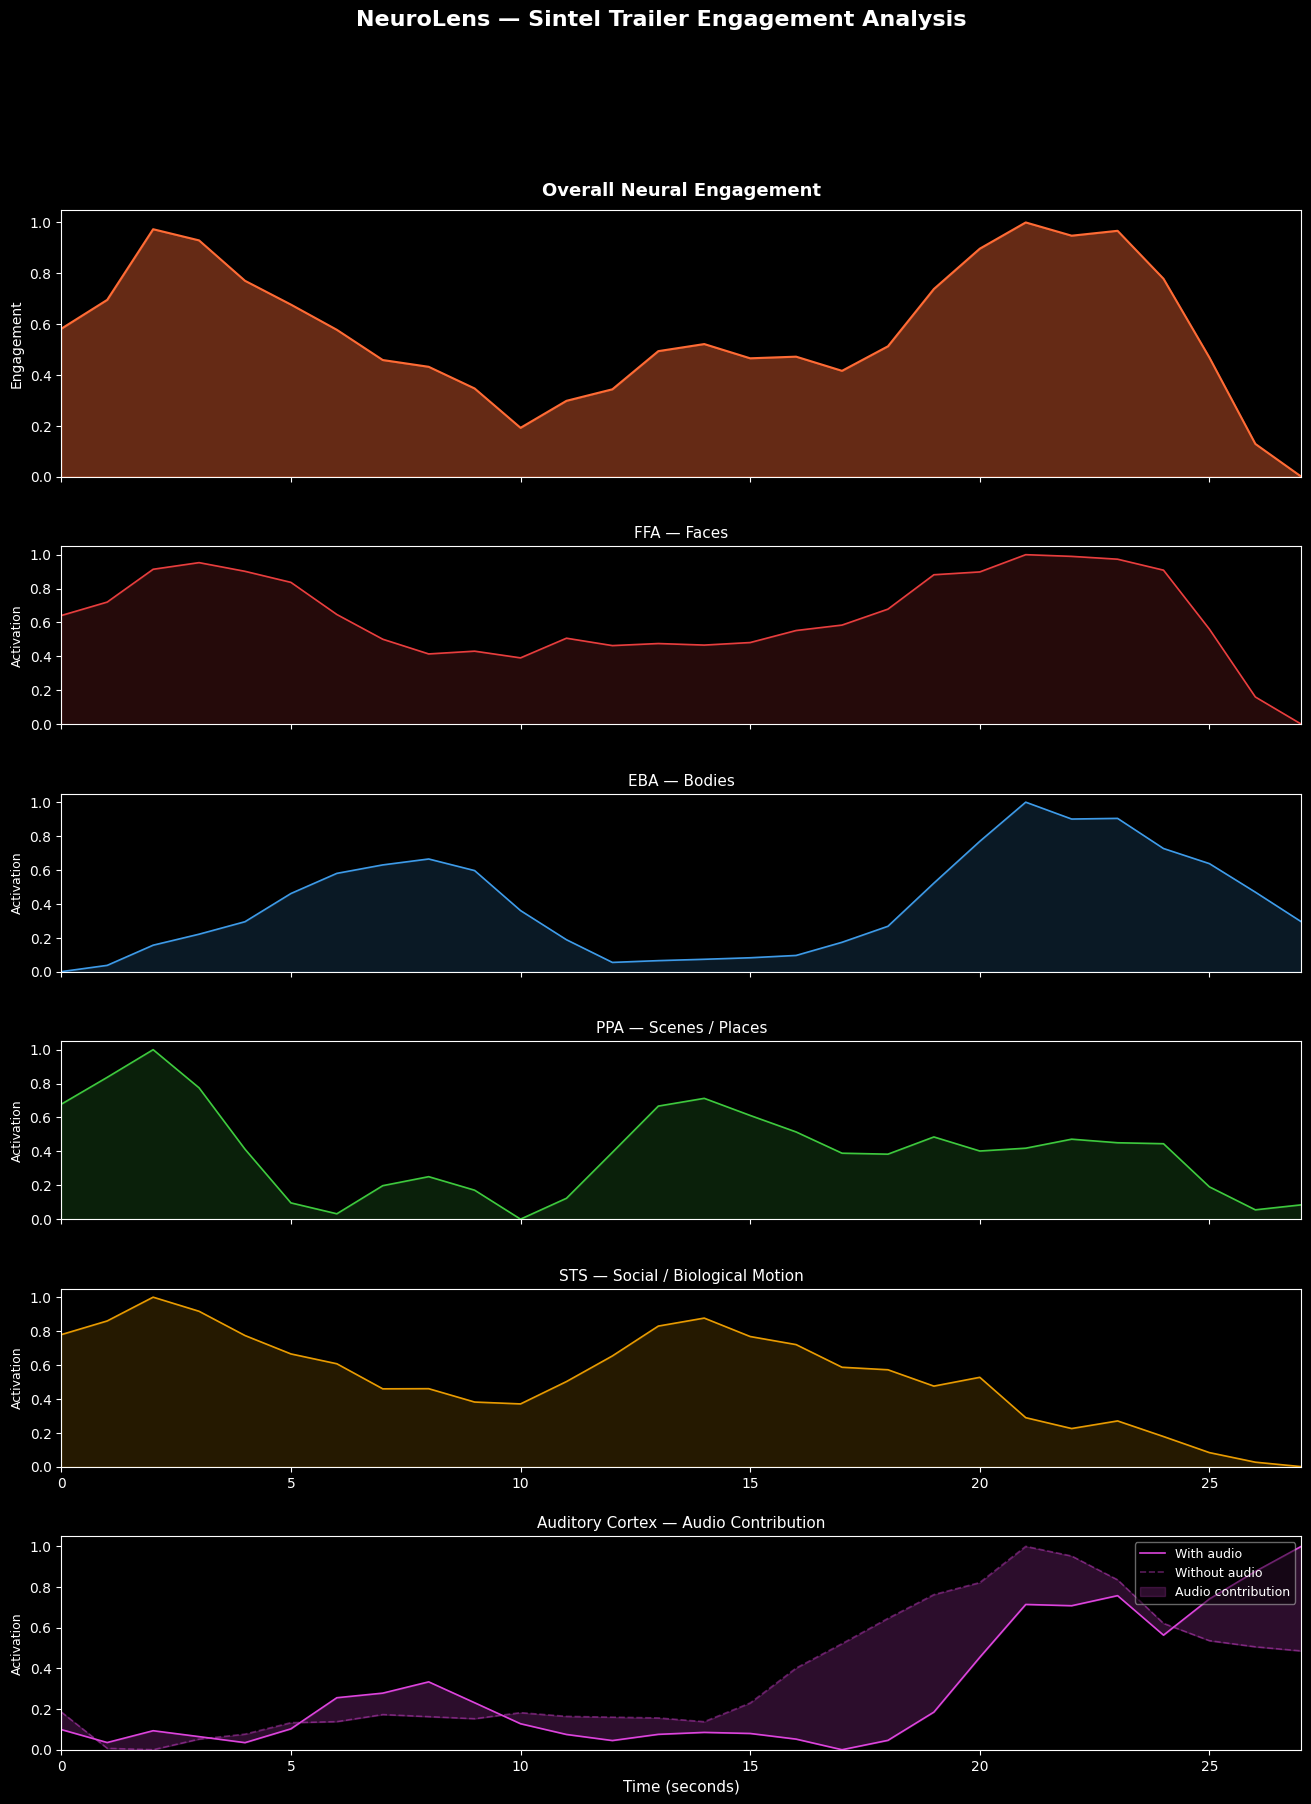


✅ Chart saved to /home/kelvinlow/projects/neurolens/output/neurolens_output.png


In [18]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Use dark theme to match Meta demo aesthetic
plt.style.use('dark_background')

time_axis = np.arange(T)
time_axis_audio = np.arange(min_len)

fig = plt.figure(figsize=(16, 20))
gs = gridspec.GridSpec(6, 1, hspace=0.35, height_ratios=[1.5, 1, 1, 1, 1, 1.2])

COLORS = {
    'engagement_overall': '#FF6B35',
    'ffa_faces':          '#FF4444',
    'eba_bodies':         '#44AAFF',
    'ppa_scenes':         '#44DD44',
    'sts_social':         '#FFAA00',
    'auditory':           '#DD44DD',
}

LABELS = {
    'engagement_overall': 'Overall Engagement',
    'ffa_faces':          'FFA — Faces',
    'eba_bodies':         'EBA — Bodies',
    'ppa_scenes':         'PPA — Scenes / Places',
    'sts_social':         'STS — Social / Biological Motion',
    'auditory':           'Auditory Cortex',
}

# --- Chart 1: Overall engagement (area) ---
ax0 = fig.add_subplot(gs[0])
ax0.fill_between(time_axis, roi_normed['engagement_overall'],
                 alpha=0.4, color=COLORS['engagement_overall'])
ax0.plot(time_axis, roi_normed['engagement_overall'],
         color=COLORS['engagement_overall'], linewidth=1.5)
ax0.set_ylabel('Engagement', fontsize=10)
ax0.set_title('Overall Neural Engagement', fontsize=13, fontweight='bold', pad=10)
ax0.set_xlim(0, T - 1)
ax0.set_ylim(0, 1.05)
ax0.tick_params(labelbottom=False)

# --- Charts 2-5: Individual ROIs (lines) ---
roi_order = ['ffa_faces', 'eba_bodies', 'ppa_scenes', 'sts_social']
for idx, roi_name in enumerate(roi_order):
    ax = fig.add_subplot(gs[idx + 1])
    ax.plot(time_axis, roi_normed[roi_name],
            color=COLORS[roi_name], linewidth=1.2, alpha=0.9)
    ax.fill_between(time_axis, roi_normed[roi_name],
                    alpha=0.15, color=COLORS[roi_name])
    ax.set_ylabel('Activation', fontsize=9)
    ax.set_title(LABELS[roi_name], fontsize=11, pad=6)
    ax.set_xlim(0, T - 1)
    ax.set_ylim(0, 1.05)
    if idx < len(roi_order) - 1:
        ax.tick_params(labelbottom=False)

# --- Chart 6: Auditory — with vs without audio ---
ax5 = fig.add_subplot(gs[5])
aud_full_normed = normalize_01(aud_full)
aud_noaudio_normed = normalize_01(aud_noaudio)
ax5.plot(time_axis_audio, aud_full_normed,
         color=COLORS['auditory'], linewidth=1.2, label='With audio')
ax5.plot(time_axis_audio, aud_noaudio_normed,
         color=COLORS['auditory'], linewidth=1.2, alpha=0.4,
         linestyle='--', label='Without audio')
ax5.fill_between(time_axis_audio, aud_noaudio_normed, aud_full_normed,
                 alpha=0.2, color=COLORS['auditory'],
                 label='Audio contribution')
ax5.set_ylabel('Activation', fontsize=9)
ax5.set_title(LABELS['auditory'] + ' — Audio Contribution', fontsize=11, pad=6)
ax5.set_xlabel('Time (seconds)', fontsize=11)
ax5.set_xlim(0, min_len - 1)
ax5.set_ylim(0, 1.05)
ax5.legend(loc='upper right', fontsize=9, framealpha=0.5)

fig.suptitle('NeuroLens — Sintel Trailer Engagement Analysis',
             fontsize=16, fontweight='bold', y=0.98)

plt.savefig(str(OUTPUT_DIR / 'neurolens_output.png'), dpi=150, bbox_inches='tight',
            facecolor='black', edgecolor='none')
plt.show()
print(f'\n✅ Chart saved to {OUTPUT_DIR / "neurolens_output.png"}')


## 14. Export Structured JSON

Build the JSON output that the Flask API will return.  
This validates the exact schema the frontend will consume.

In [19]:
import json

output = {
    'video_file': str(VIDEO_PATH.name),
    'duration_seconds': int(T),
    'model': 'facebook/tribev2',
    'mesh': 'fsaverage5',
    'roi_vertex_counts': {name: int(mask.sum()) for name, mask in roi_masks.items()},
    'timesteps': [],
}

for t in range(T):
    step = {
        't': t,
        'engagement_overall': round(float(roi_normed['engagement_overall'][t]), 4),
        'regions': {
            'ffa_faces':  round(float(roi_normed['ffa_faces'][t]), 4),
            'eba_bodies': round(float(roi_normed['eba_bodies'][t]), 4),
            'ppa_scenes': round(float(roi_normed['ppa_scenes'][t]), 4),
            'sts_social': round(float(roi_normed['sts_social'][t]), 4),
            'auditory':   round(float(roi_normed['auditory'][t]), 4),
        },
    }
    # Add audio contribution if within range
    if t < min_len:
        step['audio_contribution'] = round(float(audio_contribution_normed[t]), 4)
    else:
        step['audio_contribution'] = None
    output['timesteps'].append(step)

# Save to file
output_path = OUTPUT_DIR / 'neurolens_output.json'
with open(output_path, 'w') as f:
    json.dump(output, f, indent=2)

print(f'✅ JSON exported to {output_path}')
print(f'   {len(output["timesteps"])} timesteps')
print(f'\nSample (t=5):')
print(json.dumps(output['timesteps'][min(5, T-1)], indent=2))


✅ JSON exported to /home/kelvinlow/projects/neurolens/output/neurolens_output.json
   28 timesteps

Sample (t=5):
{
  "t": 5,
  "engagement_overall": 0.6768,
  "regions": {
    "ffa_faces": 0.8367,
    "eba_bodies": 0.461,
    "ppa_scenes": 0.0959,
    "sts_social": 0.6651,
    "auditory": 0.1027
  },
  "audio_contribution": 0.0475
}


In [20]:
import torch

for i in range(torch.cuda.device_count()):
    current = torch.cuda.memory_allocated(i) / 1e9
    peak = torch.cuda.max_memory_allocated(i) / 1e9
    total = torch.cuda.get_device_properties(i).total_memory / 1e9
    bar = '█' * int(peak / total * 30) + '░' * (30 - int(peak / total * 30))
    print(f'GPU {i} ({torch.cuda.get_device_properties(i).name}):')
    print(f'  Current: {current:.2f} GB')
    print(f'  Peak:    {peak:.2f} GB')
    print(f'  Total:   {total:.2f} GB')
    print(f'  Usage:   {bar} {peak/total*100:.1f}%')
    print()

GPU 0 (NVIDIA GeForce RTX 4090):
  Current: 0.72 GB
  Peak:    10.88 GB
  Total:   25.26 GB
  Usage:   ████████████░░░░░░░░░░░░░░░░░░ 43.1%

GPU 1 (NVIDIA GeForce RTX 4090):
  Current: 0.00 GB
  Peak:    0.00 GB
  Total:   25.26 GB
  Usage:   ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ 0.0%



## 15. Summary

This notebook validated the full NeuroLens pipeline:

| Step | Status |
|------|--------|
| TRIBE v2 model loading | ✅ |
| Video inference (full) | ✅ |
| Raw output inspection | ✅ |
| ROI vertex mapping (Destrieux atlas) | ✅ |
| Per-region timeseries extraction | ✅ |
| Audio-stripped re-inference | ✅ |
| Audio contribution analysis | ✅ |
| Engagement visualisation | ✅ |
| JSON schema export | ✅ |

**Next step:** Use the validated code from this notebook to build `app.py` (Flask API).